# Affinité client × macro + segmentation K-means

Notebook unique : **clustering** sur `category_macro`, **recommandations fines** sur la feuille de `category_name` (dernier segment du chemin).

Objectif : matrice client × macro pour **K-means** ; en parallèle agrégation client × **feuille** (`category_leaf`) pour des reco produit plus fines (ex. Manette vs macro GAMING).

**Alignement avec `rfm_segment.ipynb`** :
- `order_state == "sale"` uniquement  
- même **`category_macro`** (avant-dernier segment de `category_name`, séparateur ` / `)  
- même **fenêtre temporelle** : **`RFM_WINDOW_MONTHS`** (`None` = historique complet ; `12` = 12 derniers mois)

**Sorties** : `data/customer_kmeans.csv` — clustering sur **macros** ; reco **macro** + reco **feuille** (`recommended_leaf_*`, dernier segment de `category_name`), `cluster_profile_macro`, jointure RFM (`Tag_Interest` si présent), bundle joblib **`MODEL_PATH`**.


In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = Path.cwd()
DATA_SALES = ROOT / "data" / "sales_enriched.csv"
DATA_RFM = ROOT / "data" / "rfm_segments.csv"
EXPORT_KMEANS = ROOT / "data" / "customer_recommendation.csv"
MODEL_DIR = ROOT / "models"
MODEL_PATH = MODEL_DIR / "customer_recommendation_kmeans_v1.joblib"

In [2]:
CATEGORY_PATH_SEP = " / "


def category_macro_from_path(name) -> str:
    if pd.isna(name) or not str(name).strip():
        return "UNKNOWN"
    parts = [p.strip() for p in str(name).split(CATEGORY_PATH_SEP) if p.strip()]
    if len(parts) < 2:
        return parts[0] if parts else "UNKNOWN"
    return parts[-2]


def category_leaf_from_path(name) -> str:
    """Dernier segment du chemin (sous-catégorie fine, ex. Manette, Casques Gaming)."""
    if pd.isna(name) or not str(name).strip():
        return "UNKNOWN"
    parts = [p.strip() for p in str(name).split(CATEGORY_PATH_SEP) if p.strip()]
    return parts[-1] if parts else "UNKNOWN"


df = pd.read_csv(DATA_SALES, parse_dates=["sale_date"])
df["category_macro"] = df["category_name"].map(category_macro_from_path)
df_sales = df.loc[df["order_state"].eq("sale")].copy()

REFERENCE_DATE = df_sales["sale_date"].max().normalize()

RFM_WINDOW_MONTHS = None  # None = historique complet ; 12 = 12 derniers mois, etc.

if RFM_WINDOW_MONTHS is None:
    WINDOW_START = df_sales["sale_date"].min().normalize()
else:
    WINDOW_START = REFERENCE_DATE - pd.DateOffset(months=int(RFM_WINDOW_MONTHS))

df_win = df_sales.loc[
    (df_sales["sale_date"] >= WINDOW_START) & (df_sales["sale_date"] <= REFERENCE_DATE)
].copy()

df_win["category_leaf"] = df_win["category_name"].map(category_leaf_from_path)

print(f"Référence : {REFERENCE_DATE.date()} | Fenêtre : {WINDOW_START.date()} → {REFERENCE_DATE.date()}")
print(
    f"Lignes : {len(df_win):,} | Clients : {df_win['partner_id'].nunique():,} "
    f"| Macros : {df_win['category_macro'].nunique()} | Feuilles (category_leaf) : {df_win['category_leaf'].nunique()}"
)

/tmp/ipykernel_556633/3759453911.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(DATA_SALES, parse_dates=["sale_date"])


Référence : 2026-03-11 | Fenêtre : 2022-01-02 → 2026-03-11
Lignes : 63,866 | Clients : 26,745 | Macros : 23 | Feuilles (category_leaf) : 61


### Agrégations client × macro

- **`category_leaf`** : dernier segment de `category_name` (reco fine : Manette, Casques Gaming, …).  
- **`ca_macro`** : somme `price_subtotal` pour ce couple (client, macro).  
- **`ca_partner_total`** : CA total du client sur la fenêtre (dénominateur **part du wallet**).  
- **`share_wallet`** : `ca_macro / ca_partner_total`.  
- **`nb_lignes`**, **`nb_commandes`** (`order_id` distincts), **`nb_produits`** (`product_id` distincts).  
- **`last_purchase_macro`**, **`recency_macro_days`** : récence **dans cette macro** (pas la récence globale RFM).

In [3]:
ca_partner = df_win.groupby("partner_id", as_index=False)["price_subtotal"].sum().rename(
    columns={"price_subtotal": "ca_partner_total"}
)

agg_macro = (
    df_win.groupby(["partner_id", "category_macro"], as_index=False)
    .agg(
        ca_macro=("price_subtotal", "sum"),
        nb_lignes=("order_id", "size"),
        nb_commandes=("order_id", "nunique"),
        nb_produits=("product_id", "nunique"),
        last_purchase_macro=("sale_date", "max"),
    )
)

affinity = agg_macro.merge(ca_partner, on="partner_id", how="left")
affinity["share_wallet"] = (affinity["ca_macro"] / affinity["ca_partner_total"]).replace([np.inf, -np.inf], np.nan)
affinity["recency_macro_days"] = (REFERENCE_DATE - affinity["last_purchase_macro"]).dt.days.astype("int64")

agg_leaf = (
    df_win.groupby(["partner_id", "category_leaf"], as_index=False)
    .agg(ca_leaf=("price_subtotal", "sum"))
)
agg_leaf = agg_leaf.merge(ca_partner, on="partner_id", how="left")
agg_leaf["share_wallet_leaf"] = (agg_leaf["ca_leaf"] / agg_leaf["ca_partner_total"]).replace(
    [np.inf, -np.inf], np.nan
)

_names = df_win.sort_values("sale_date").groupby("partner_id")["partner_name"].agg(
    lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0]
)
affinity = affinity.merge(_names.rename("partner_name"), on="partner_id", how="left")

affinity["reference_date"] = str(REFERENCE_DATE.date())
affinity["window_start"] = str(WINDOW_START.date())
affinity["window_end"] = str(REFERENCE_DATE.date())
affinity["window_months"] = "full" if RFM_WINDOW_MONTHS is None else str(int(RFM_WINDOW_MONTHS))

print(f"Lignes (client × macro) : {len(affinity):,} | client × feuille : {len(agg_leaf):,}")
display(affinity.head(12))

Lignes (client × macro) : 36,342 | client × feuille : 44,622


,partner_id,category_macro,ca_macro,nb_lignes,nb_commandes,nb_produits,last_purchase_macro,ca_partner_total,share_wallet,recency_macro_days,partner_name,reference_date,window_start,window_end,window_months
0,38,SMARTPHONES,3341440.00,1,1,1,2025-08-30,3341440.00,1.000000,193,ANDRIANAMBININA Kevin Adrian,2026-03-11,2022-01-02,2026-03-11,full
1,174,SMARTPHONES,303940.40,1,1,1,2026-01-29,303940.40,1.000000,41,RAHARISON Gisèle,2026-03-11,2022-01-02,2026-03-11,full
2,418,GAMING,65365.20,1,1,1,2022-12-21,27765769.72,0.002354,1176,MASS' IN,2026-03-11,2022-01-02,2026-03-11,full
3,418,IMPRIMANTES,7444588.75,95,56,8,2026-02-22,27765769.72,0.268121,17,MASS' IN,2026-03-11,2022-01-02,2026-03-11,full
4,418,INFORMATIQUE,738847.83,6,6,5,2024-12-02,27765769.72,0.026610,464,MASS' IN,2026-03-11,2022-01-02,2026-03-11,full
5,418,LAPTOPS,16953565.59,14,10,13,2025-04-01,27765769.72,0.610592,344,MASS' IN,2026-03-11,2022-01-02,2026-03-11,full
6,418,SMARTPHONES,2533138.71,2,2,2,2024-03-04,27765769.72,0.091232,737,MASS' IN,2026-03-11,2022-01-02,2026-03-11,full
7,418,STOCKAGE,30263.64,1,1,1,2023-11-09,27765769.72,0.001090,853,MASS' IN,2026-03-11,2022-01-02,2026-03-11,full
8,420,GAMING,22000.00,2,1,2,2024-07-19,22000.00,1.000000,600,RAHARISON Gisèle,2026-03-11,2022-01-02,2026-03-11,full
9,425,GAMING,178000.00,1,1,1,2024-08-13,4136000.00,0.043037,575,ABDEALY ALY ASGAR,2026-03-11,2022-01-02,2026-03-11,full


### Jointure RFM (optionnelle)

Enrichit chaque ligne avec le **segment RFM** du client (`rfm_segments.csv` généré par `rfm_segment.ipynb`). Les clients absents du fichier RFM restent avec `segment` / scores NaN.

In [4]:
rfm_cols_keep = [
    "partner_id",
    "segment",
    "recency_days",
    "frequency",
    "monetary",
    "R_score",
    "F_score",
    "M_score",
    "Tag_Interest",
    "interest_tag",
]

if DATA_RFM.exists():
    rfm = pd.read_csv(DATA_RFM)
    _have = [c for c in rfm_cols_keep if c in rfm.columns]
    rfm_sub = rfm[_have].drop_duplicates(subset=["partner_id"])
    affinity_rfm = affinity.merge(rfm_sub, on="partner_id", how="left")
    print(f"Jointure RFM : {affinity_rfm['segment'].notna().sum():,} lignes avec segment renseigné")
else:
    affinity_rfm = affinity.copy()
    print(f"Fichier absent : {DATA_RFM} — export sans colonnes RFM.")

display(affinity_rfm.head(8))

Jointure RFM : 36,342 lignes avec segment renseigné


,partner_id,category_macro,ca_macro,nb_lignes,nb_commandes,nb_produits,last_purchase_macro,ca_partner_total,share_wallet,recency_macro_days,...,window_end,window_months,segment,recency_days,frequency,monetary,R_score,F_score,M_score,Tag_Interest
0,38,SMARTPHONES,3341440.00,1,1,1,2025-08-30,3341440.00,1.000000,193,...,2026-03-11,full,Fidèles,193,1,3341440.00,5,1,5,SMARTPHONES
1,174,SMARTPHONES,303940.40,1,1,1,2026-01-29,303940.40,1.000000,41,...,2026-03-11,full,Fidèles,41,1,303940.40,5,1,2,SMARTPHONES
2,418,GAMING,65365.20,1,1,1,2022-12-21,27765769.72,0.002354,1176,...,2026-03-11,full,Champions,17,74,27765769.72,5,5,5,LAPTOPS
3,418,IMPRIMANTES,7444588.75,95,56,8,2026-02-22,27765769.72,0.268121,17,...,2026-03-11,full,Champions,17,74,27765769.72,5,5,5,LAPTOPS
4,418,INFORMATIQUE,738847.83,6,6,5,2024-12-02,27765769.72,0.026610,464,...,2026-03-11,full,Champions,17,74,27765769.72,5,5,5,LAPTOPS
5,418,LAPTOPS,16953565.59,14,10,13,2025-04-01,27765769.72,0.610592,344,...,2026-03-11,full,Champions,17,74,27765769.72,5,5,5,LAPTOPS
6,418,SMARTPHONES,2533138.71,2,2,2,2024-03-04,27765769.72,0.091232,737,...,2026-03-11,full,Champions,17,74,27765769.72,5,5,5,LAPTOPS
7,418,STOCKAGE,30263.64,1,1,1,2023-11-09,27765769.72,0.001090,853,...,2026-03-11,full,Champions,17,74,27765769.72,5,5,5,LAPTOPS


In [5]:
# Pas d’export CSV « long » client × macro : seul `customer_kmeans.csv` contient le résultat ML.
# Évite collision de noms entre récence / F / M RFM globaux et colonnes homonymes éventuelles.
_rfm_rename = {"recency_days": "rfm_recency_days", "frequency": "rfm_frequency", "monetary": "rfm_monetary"}
for old, new in _rfm_rename.items():
    if old in affinity_rfm.columns:
        affinity_rfm = affinity_rfm.rename(columns={old: new})

### Utilisation rapide (DataFrame `affinity_rfm` en mémoire)

- **Liste « intérêt GAMING »** : filtrer `category_macro == "GAMING"`, trier par `share_wallet` ou `ca_macro` décroissant.  
- **Croiser avec le segment** : filtrer `segment.isin(["Champions", "Fidèles"])` pour ciblage premium.  
- La **récence dans la macro** (`recency_macro_days`) sert à repérer un intérêt **récent** vs **ancien** dans cet univers.  
- **Résultat exporté** : `data/customer_kmeans.csv` — `cluster_affinity` (macros), `recommended_macro_*`, **`recommended_leaf_*`** (ex. Manette, Casques Gaming), `cluster_profile_macro`, `Tag_Interest` (si RFM joint).

In [6]:
# Exemple : top 15 clients par part de wallet sur une macro (à adapter)
MACRO_EX = affinity_rfm["category_macro"].value_counts().index[0]
top_macro = (
    affinity_rfm.loc[affinity_rfm["category_macro"].eq(MACRO_EX)]
    .sort_values("share_wallet", ascending=False)
    .head(15)
)
print(f"Top share_wallet — macro = {MACRO_EX!r}")
_demo_cols = [
    "partner_id",
    "partner_name",
    "share_wallet",
    "ca_macro",
    "recency_macro_days",
]
if "segment" in top_macro.columns:
    _demo_cols.append("segment")
display(top_macro[_demo_cols])

Top share_wallet — macro = 'INFORMATIQUE'


,partner_id,partner_name,share_wallet,ca_macro,recency_macro_days,segment
36340,57219,RAMAHAROSATA Tiavina,1.0,449000.0,0,Fidèles
36308,57161,ANDRIANADISON LANTO TSIHAFINDRAHASINA NANTENAINA,1.0,900000.0,3,Fidèles
36307,57160,ANDRIANARIVO Priscilla,1.0,1951000.0,3,Champions
36296,57149,ANDRIANARIVELO FANILO,1.0,50000.0,4,Fidèles
36295,57148,RAKOTONDRANALY Tsiory,1.0,1749000.0,4,Champions
36292,57144,RANDRIARILALA Tefinanahary,1.0,1749000.0,4,Champions
36288,57140,RASAMOELY Aina Natolotra Jonathan,1.0,1749000.0,4,Champions
36287,57139,GAETAN,1.0,900000.0,4,Fidèles
36286,57138,LAHIBE Nadji,1.0,900000.0,4,Fidèles
36284,57135,ANDRIAMAHEFA Rovasoa Njaratiana,1.0,900000.0,4,Fidèles


## K-means — profils d'affinité (centres d'intérêt)

On regroupe les clients dont la **répartition du wallet entre macros** (`share_wallet`) se ressemble.

- **Entrée** : matrice **large** `partner_id` × `category_macro` (`share_wallet`, 0 si absent).  
- **Prétraitement** : `StandardScaler`.  
- **Choix de k** : graphiques **coude** + **silhouette** (diagnostic) ; **k final fixé à 4** (`N_CLUSTERS_BUSINESS`) pour 4 profils d’affinité métier (reco macro).  
- **Export client** : `recommended_macro_*` (parts macro + fallback cluster) et **`recommended_leaf_*`** (feuille = dernier segment de `category_name`, fallback CA feuilles dans le cluster).  
- **Sorties intermédiaires** : `cluster_affinity`, heatmap des profils, **PCA 3D** puis **PCA 2D** (vue compacte).  
- **Export** : **`MODEL_PATH`** (scaler + KMeans + noms de macros + métadonnées).

> Exécuter les cellules qui construisent **`affinity_rfm`** avant cette section.


Métriques k (inertie + silhouette) :


,k,inertia,silhouette_sample,dist_to_elbow_line
0,2,528049.957380,0.292815,0.000000
1,3,495120.846128,0.353089,0.172077
2,4,468800.326923,0.504212,0.108929
3,5,441130.455476,0.520859,0.093809
4,6,413914.804079,0.583451,0.062522
5,7,386858.699342,0.573003,0.025555
6,8,359482.015303,0.697061,0.000000


k au coude (heuristique distance) : 3
k au meilleur silhouette : 8
k retenu pour le modèle : 4 — métier N_CLUSTERS_BUSINESS=4 (réf. silhouette max k=8, coude ≈ 3)


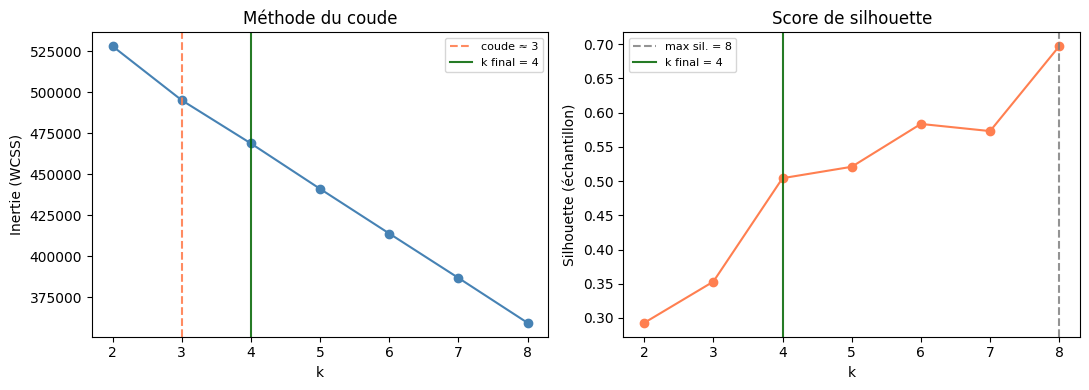

Modèle exporté : /home/raphael/Projects/jedha/segmentation/models/customer_recommendation_kmeans_v1.joblib
Clients étiquetés : 26,745


cluster_affinity
0    15802
1      969
2     5703
3     4271
Name: count, dtype: int64

In [7]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# Matrice large (share_wallet)
wide_share = affinity_rfm.pivot_table(
    index="partner_id",
    columns="category_macro",
    values="share_wallet",
    aggfunc="sum",
    fill_value=0.0,
)
macro_cols = list(wide_share.columns)
X_raw = wide_share[macro_cols].to_numpy(dtype=np.float64)
partner_ids = wide_share.index.to_numpy()

scaler_aff = StandardScaler()
X_scaled = scaler_aff.fit_transform(X_raw)

if X_scaled.shape[0] < 2:
    raise ValueError("Au moins 2 clients dans wide_share sont nécessaires pour K-means.")
if X_scaled.shape[1] < 1:
    raise ValueError("Aucune colonne macro : vérifier category_macro / df_win.")

# --- Grille k : inertie (coude) + silhouette (diagnostic ; k final fixé métier ci-dessous)
K_RANGE = range(2, min(9, X_scaled.shape[0] + 1))
_sil_n = min(8000, X_scaled.shape[0])

rows = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    inertia = float(km.inertia_)
    if len(np.unique(labels_k)) < 2:
        sil = np.nan
    else:
        sil = silhouette_score(
            X_scaled,
            labels_k,
            sample_size=min(_sil_n, X_scaled.shape[0]),
            random_state=42,
        )
    rows.append({"k": k, "inertia": inertia, "silhouette_sample": sil})

k_metrics = pd.DataFrame(rows)

# Indice « coude » : distance max au segment [premier point → dernier point] (courbe inertie vs k)
ks = k_metrics["k"].to_numpy(dtype=float)
y = k_metrics["inertia"].to_numpy(dtype=float)
p0 = np.array([ks[0], y[0]])
p1 = np.array([ks[-1], y[-1]])
line = p1 - p0
line_len_sq = float(np.dot(line, line)) + 1e-12
dists = []
for i in range(len(ks)):
    p = np.array([ks[i], y[i]])
    t = np.dot(p - p0, line) / line_len_sq
    t = np.clip(t, 0.0, 1.0)
    proj = p0 + t * line
    dists.append(float(np.linalg.norm(p - proj)))

k_metrics["dist_to_elbow_line"] = dists
k_elbow = int(k_metrics.loc[k_metrics["dist_to_elbow_line"].idxmax(), "k"])

# Meilleur k par silhouette (sur la grille, lecture seulement)
k_sil_best = int(k_metrics.loc[k_metrics["silhouette_sample"].idxmax(), "k"])

# --- Fixe métier : 4 profils d’affinité (question « quelle macro suggérer »)
N_CLUSTERS_BUSINESS = 4
N_CLUSTERS = int(N_CLUSTERS_BUSINESS)
k_choice_reason = (
    f"métier N_CLUSTERS_BUSINESS={N_CLUSTERS_BUSINESS} "
    f"(réf. silhouette max k={k_sil_best}, coude ≈ {k_elbow})"
)

print("Métriques k (inertie + silhouette) :")
display(k_metrics)

print(f"k au coude (heuristique distance) : {k_elbow}")
print(f"k au meilleur silhouette : {k_sil_best}")
print(f"k retenu pour le modèle : {N_CLUSTERS} — {k_choice_reason}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(k_metrics["k"], k_metrics["inertia"], marker="o", color="steelblue")
axes[0].axvline(k_elbow, color="coral", linestyle="--", alpha=0.9, label=f"coude ≈ {k_elbow}")
axes[0].axvline(N_CLUSTERS, color="darkgreen", linestyle="-", alpha=0.85, label=f"k final = {N_CLUSTERS}")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertie (WCSS)")
axes[0].set_title("Méthode du coude")
axes[0].legend(fontsize=8)
axes[0].set_xticks(list(K_RANGE))

axes[1].plot(k_metrics["k"], k_metrics["silhouette_sample"], marker="o", color="coral")
axes[1].axvline(k_sil_best, color="gray", linestyle="--", alpha=0.85, label=f"max sil. = {k_sil_best}")
axes[1].axvline(N_CLUSTERS, color="darkgreen", linestyle="-", alpha=0.85, label=f"k final = {N_CLUSTERS}")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette (échantillon)")
axes[1].set_title("Score de silhouette")
axes[1].legend(fontsize=8)
axes[1].set_xticks(list(K_RANGE))

plt.tight_layout()
plt.show()

# --- Fit final + export du modèle (scaler + kmeans + métadonnées)
kmeans_aff = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
labels_aff = kmeans_aff.fit_predict(X_scaled)

# Macro dominante par cluster (moyenne des parts share_wallet dans le groupe)
_prof_cl = wide_share[macro_cols].copy()
_prof_cl["cluster_affinity"] = labels_aff
_cluster_means = _prof_cl.groupby("cluster_affinity")[macro_cols].mean()
cluster_profile_macro_by_id = _cluster_means.idxmax(axis=1).to_dict()

MODEL_DIR.mkdir(parents=True, exist_ok=True)

bundle = {
    "kmeans": kmeans_aff,
    "scaler": scaler_aff,
    "macro_cols": macro_cols,
    "n_clusters": N_CLUSTERS,
    "k_range": list(K_RANGE),
    "k_elbow_hint": k_elbow,
    "k_silhouette_best": k_sil_best,
    "k_metrics": k_metrics,
    "k_choice_reason": k_choice_reason,
    "feature_matrix": "share_wallet_wide_scaled",
    "random_state": 42,
}
joblib.dump(bundle, MODEL_PATH)
print(f"Modèle exporté : {MODEL_PATH.resolve()}")

clusters_affinity = pd.DataFrame(
    {"partner_id": partner_ids, "cluster_affinity": labels_aff}
)

_meta_cols = ["partner_id", "partner_name"]
if "segment" in affinity_rfm.columns:
    _meta_cols.append("segment")
for _c in ("Tag_Interest", "interest_tag"):
    if _c in affinity_rfm.columns and _c not in _meta_cols:
        _meta_cols.append(_c)
_meta = affinity_rfm[_meta_cols].drop_duplicates(subset=["partner_id"])
clusters_affinity = clusters_affinity.merge(_meta, on="partner_id", how="left")

clusters_affinity["cluster_profile_macro"] = clusters_affinity["cluster_affinity"].map(
    cluster_profile_macro_by_id
)

# Ordre des macros par part moyenne dans chaque cluster (fallback si le client est mono-macro)
cluster_macro_rank = {
    int(cl): _cluster_means.loc[cl].sort_values(ascending=False).index.astype(str).tolist()
    for cl in _cluster_means.index
}

_ws = wide_share.reindex(clusters_affinity["partner_id"])
_mat = _ws[macro_cols].to_numpy(dtype=np.float64)
_rec_pri, _rec_sec, _rec_ter = [], [], []
for i in range(len(_mat)):
    row = _mat[i]
    cl = int(clusters_affinity["cluster_affinity"].iloc[i])
    rank = cluster_macro_rank.get(cl, [])
    ord_idx = np.argsort(-row)
    positives = [str(macro_cols[int(j)]) for j in ord_idx if row[j] > 0]

    if positives:
        pri, sec, ter = positives[0], None, None
        if len(positives) > 1:
            sec = positives[1]
        if len(positives) > 2:
            ter = positives[2]
    else:
        pri = rank[0] if rank else None
        sec = rank[1] if len(rank) > 1 else None
        ter = rank[2] if len(rank) > 2 else None

    used = {x for x in (pri, sec, ter) if x is not None}
    if sec is None and pri is not None:
        for m in rank:
            if m != pri:
                sec = m
                break
    used = {x for x in (pri, sec, ter) if x is not None}
    if ter is None:
        for m in rank:
            if m not in used:
                ter = m
                break

    _rec_pri.append(pri)
    _rec_sec.append(sec)
    _rec_ter.append(ter)
clusters_affinity["recommended_macro_primary"] = _rec_pri
clusters_affinity["recommended_macro_secondary"] = _rec_sec
clusters_affinity["recommended_macro_tertiary"] = _rec_ter

# --- Reco fines (dernier segment de category_name) ; fallback = feuilles les plus vendues dans le même cluster
_leaf_cl = agg_leaf.merge(
    clusters_affinity[["partner_id", "cluster_affinity"]],
    on="partner_id",
    how="left",
)
_leaf_sum = _leaf_cl.groupby(["cluster_affinity", "category_leaf"], as_index=False)["ca_leaf"].sum()
cluster_leaf_rank = {}
for cl in _leaf_sum["cluster_affinity"].unique():
    sub = _leaf_sum[_leaf_sum["cluster_affinity"].eq(cl)].sort_values("ca_leaf", ascending=False)
    cluster_leaf_rank[int(cl)] = sub["category_leaf"].astype(str).tolist()

_lp, _ls, _lt = [], [], []
for i in range(len(clusters_affinity)):
    pid = int(clusters_affinity["partner_id"].iloc[i])
    cl = int(clusters_affinity["cluster_affinity"].iloc[i])
    rank = cluster_leaf_rank.get(cl, [])
    sub = agg_leaf.loc[agg_leaf["partner_id"].eq(pid)].sort_values("ca_leaf", ascending=False)
    positives = sub["category_leaf"].astype(str).tolist()

    if positives:
        pri_l, sec_l, ter_l = positives[0], None, None
        if len(positives) > 1:
            sec_l = positives[1]
        if len(positives) > 2:
            ter_l = positives[2]
    else:
        pri_l = rank[0] if rank else None
        sec_l = rank[1] if len(rank) > 1 else None
        ter_l = rank[2] if len(rank) > 2 else None

    used_l = {x for x in (pri_l, sec_l, ter_l) if x is not None}
    if sec_l is None and pri_l is not None:
        for m in rank:
            if m != pri_l:
                sec_l = m
                break
    used_l = {x for x in (pri_l, sec_l, ter_l) if x is not None}
    if ter_l is None:
        for m in rank:
            if m not in used_l:
                ter_l = m
                break

    _lp.append(pri_l)
    _ls.append(sec_l)
    _lt.append(ter_l)

clusters_affinity["recommended_leaf_primary"] = _lp
clusters_affinity["recommended_leaf_secondary"] = _ls
clusters_affinity["recommended_leaf_tertiary"] = _lt

print(f"Clients étiquetés : {len(clusters_affinity):,}")
display(clusters_affinity["cluster_affinity"].value_counts().sort_index())


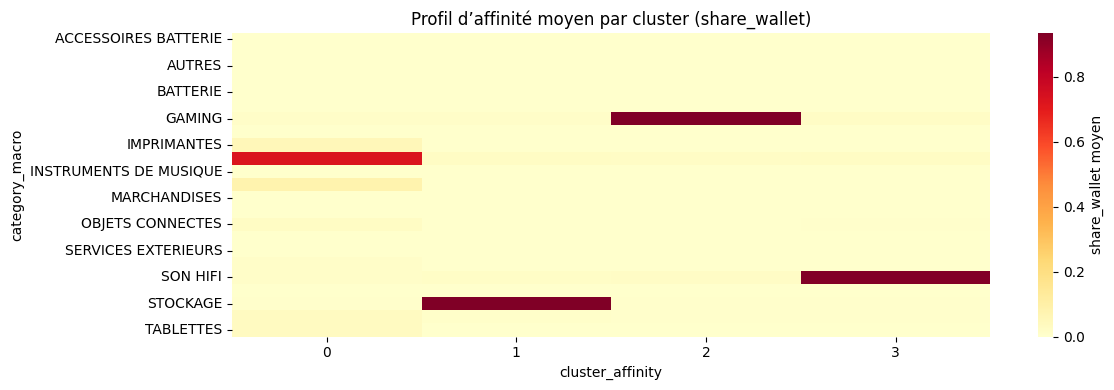

Top 3 macros par cluster (share moyen) :
  cluster 0: [('INFORMATIQUE', np.float64(0.7307)), ('LAPTOPS', np.float64(0.0838)), ('IMPRIMANTES', np.float64(0.053))]
  cluster 1: [('STOCKAGE', np.float64(0.9354)), ('INFORMATIQUE', np.float64(0.0254)), ('SON HIFI', np.float64(0.0156))]
  cluster 2: [('GAMING', np.float64(0.9358)), ('INFORMATIQUE', np.float64(0.0209)), ('SON HIFI', np.float64(0.0187))]
  cluster 3: [('SON HIFI', np.float64(0.9306)), ('INFORMATIQUE', np.float64(0.0222)), ('GAMING', np.float64(0.0215))]


In [8]:
# Profil moyen par cluster (share_wallet) — quelles macros dominent chaque groupe ?
prof = wide_share[macro_cols].copy()
prof["cluster_affinity"] = labels_aff
centers_share = prof.groupby("cluster_affinity", as_index=True)[macro_cols].mean()

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(centers_share.T, cmap="YlOrRd", ax=ax, cbar_kws={"label": "share_wallet moyen"})
ax.set_title("Profil d’affinité moyen par cluster (share_wallet)")
ax.set_xlabel("cluster_affinity")
plt.tight_layout()
plt.show()

# Top 3 macros par cluster (lecture métier)
topm = {}
for c in sorted(prof["cluster_affinity"].unique()):
    row = centers_share.loc[c].sort_values(ascending=False).head(3)
    topm[c] = list(zip(row.index, row.values.round(4)))
print("Top 3 macros par cluster (share moyen) :")
for c, triple in topm.items():
    print(f"  cluster {c}: {triple}")

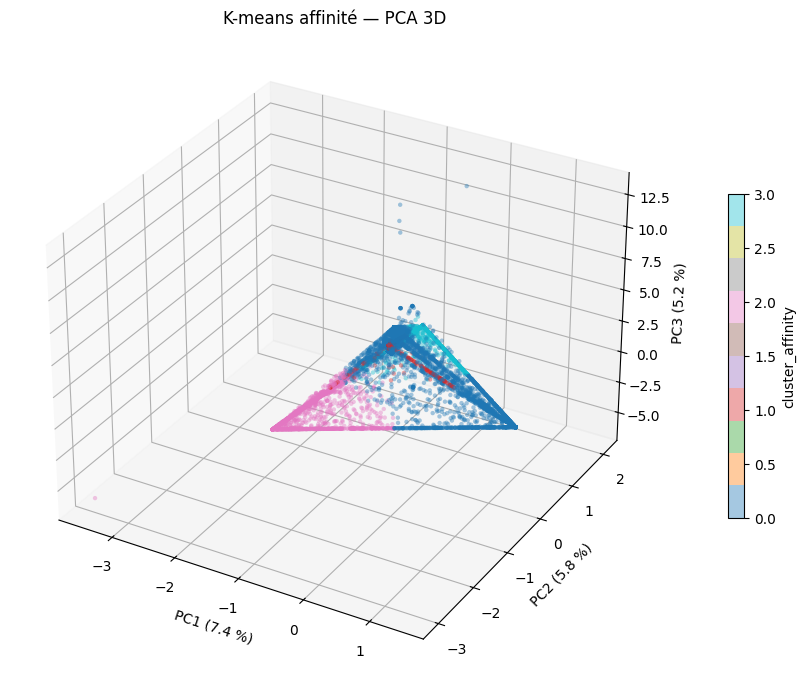

In [9]:
# Projection PCA 3D (espace scalé) — rotation interactive dans Jupyter
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

pca3 = PCA(n_components=3, random_state=42)
Z3 = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(
    Z3[:, 0],
    Z3[:, 1],
    Z3[:, 2],
    c=labels_aff,
    cmap="tab10",
    alpha=0.4,
    s=10,
    linewidths=0,
    depthshade=True,
)
ax.set_xlabel(f"PC1 ({pca3.explained_variance_ratio_[0] * 100:.1f} %)")
ax.set_ylabel(f"PC2 ({pca3.explained_variance_ratio_[1] * 100:.1f} %)")
ax.set_zlabel(f"PC3 ({pca3.explained_variance_ratio_[2] * 100:.1f} %)")
ax.set_title("K-means affinité — PCA 3D")
cbar = fig.colorbar(sc, ax=ax, shrink=0.5, pad=0.08)
cbar.set_label("cluster_affinity")
plt.tight_layout()
plt.show()


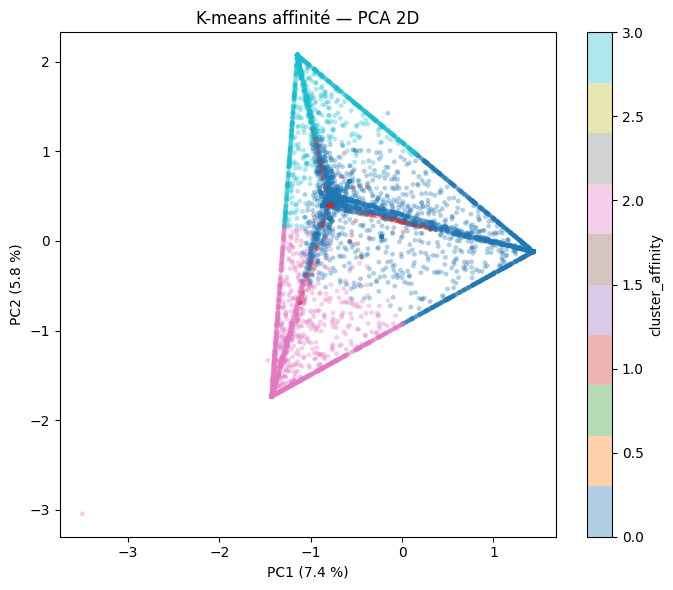

In [10]:
# Projection PCA 2D (espace scalé)
pca2 = PCA(n_components=2, random_state=42)
Z2 = pca2.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(Z2[:, 0], Z2[:, 1], c=labels_aff, cmap="tab10", alpha=0.35, s=12, linewidths=0)
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f} %)")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f} %)")
ax.set_title("K-means affinité — PCA 2D")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("cluster_affinity")
plt.tight_layout()
plt.show()


In [11]:
# Export unique : résultat ML K-means (une ligne par client)
EXPORT_KMEANS.parent.mkdir(parents=True, exist_ok=True)

out_cl = clusters_affinity.copy()
out_cl["reference_date"] = str(REFERENCE_DATE.date())
out_cl["window_start"] = str(WINDOW_START.date())
out_cl["window_end"] = str(REFERENCE_DATE.date())
out_cl["window_months"] = "full" if RFM_WINDOW_MONTHS is None else str(int(RFM_WINDOW_MONTHS))
out_cl["k_clusters"] = N_CLUSTERS
out_cl["feature_matrix"] = "share_wallet_wide_scaled_kmeans"
out_cl["model_joblib"] = str(MODEL_PATH.resolve())

out_cl.to_csv(EXPORT_KMEANS, index=False)
print(f"Export K-means : {EXPORT_KMEANS.resolve()} ({len(out_cl):,} lignes)")
print(f"Modèle associé : {out_cl['model_joblib'].iloc[0]}")
display(out_cl.head(10))

Export K-means : /home/raphael/Projects/jedha/segmentation/data/customer_recommendation.csv (26,745 lignes)
Modèle associé : /home/raphael/Projects/jedha/segmentation/models/customer_recommendation_kmeans_v1.joblib


,partner_id,cluster_affinity,partner_name,segment,Tag_Interest,cluster_profile_macro,recommended_macro_primary,recommended_macro_secondary,recommended_macro_tertiary,recommended_leaf_primary,recommended_leaf_secondary,recommended_leaf_tertiary,reference_date,window_start,window_end,window_months,k_clusters,feature_matrix,model_joblib
0,38,0,ANDRIANAMBININA Kevin Adrian,Fidèles,SMARTPHONES,INFORMATIQUE,SMARTPHONES,INFORMATIQUE,LAPTOPS,Smartphones Neufs,RESEAU,Laptops Neufs,2026-03-11,2022-01-02,2026-03-11,full,4,share_wallet_wide_scaled_kmeans,/home/raphael/Projects/jedha/segmentation/mode...
1,174,0,RAHARISON Gisèle,Fidèles,SMARTPHONES,INFORMATIQUE,SMARTPHONES,INFORMATIQUE,LAPTOPS,Smartphones Neufs,RESEAU,Laptops Neufs,2026-03-11,2022-01-02,2026-03-11,full,4,share_wallet_wide_scaled_kmeans,/home/raphael/Projects/jedha/segmentation/mode...
2,418,0,MASS' IN,Champions,LAPTOPS,INFORMATIQUE,LAPTOPS,IMPRIMANTES,SMARTPHONES,Laptops Reconditionnés,Toner et Cartouches,Imprimantes,2026-03-11,2022-01-02,2026-03-11,full,4,share_wallet_wide_scaled_kmeans,/home/raphael/Projects/jedha/segmentation/mode...
3,420,2,RAHARISON Gisèle,Dormants,GAMING,GAMING,GAMING,INFORMATIQUE,SON HIFI,Gaming Produits Dérivés,Gaming Consoles,Gaming Jeux Vidéos,2026-03-11,2022-01-02,2026-03-11,full,4,share_wallet_wide_scaled_kmeans,/home/raphael/Projects/jedha/segmentation/mode...
4,425,0,ABDEALY ALY ASGAR,Champions,LAPTOPS,INFORMATIQUE,LAPTOPS,GAMING,STOCKAGE,Laptops Neufs,Gaming Produits Dérivés,Cles USB,2026-03-11,2022-01-02,2026-03-11,full,4,share_wallet_wide_scaled_kmeans,/home/raphael/Projects/jedha/segmentation/mode...
5,442,0,ANDRIAMORATSIRESY Tsiry,À risque,INFORMATIQUE,INFORMATIQUE,INFORMATIQUE,GAMING,LAPTOPS,RESEAU,Manette,Laptops Neufs,2026-03-11,2022-01-02,2026-03-11,full,4,share_wallet_wide_scaled_kmeans,/home/raphael/Projects/jedha/segmentation/mode...
6,449,0,APPADOO.N,Dormants,TABLETTE ET TELEPHONIE,INFORMATIQUE,TABLETTE ET TELEPHONIE,INFORMATIQUE,LAPTOPS,Accessoires Telephones,RESEAU,Laptops Neufs,2026-03-11,2022-01-02,2026-03-11,full,4,share_wallet_wide_scaled_kmeans,/home/raphael/Projects/jedha/segmentation/mode...
7,456,0,Bernard Wong,Fidèles,LAPTOPS,INFORMATIQUE,LAPTOPS,STOCKAGE,INFORMATIQUE,Laptops Reconditionnés,Cles USB,Cartes Memoires,2026-03-11,2022-01-02,2026-03-11,full,4,share_wallet_wide_scaled_kmeans,/home/raphael/Projects/jedha/segmentation/mode...
8,460,0,BNI Madagascar,Fidèles,INFORMATIQUE,INFORMATIQUE,INFORMATIQUE,LAPTOPS,IMPRIMANTES,Ecrans,RESEAU,Laptops Neufs,2026-03-11,2022-01-02,2026-03-11,full,4,share_wallet_wide_scaled_kmeans,/home/raphael/Projects/jedha/segmentation/mode...
9,464,0,CABINET ATM SARL,Fidèles,IMPRIMANTES,INFORMATIQUE,IMPRIMANTES,INFORMATIQUE,LAPTOPS,Toner et Cartouches,RESEAU,Laptops Neufs,2026-03-11,2022-01-02,2026-03-11,full,4,share_wallet_wide_scaled_kmeans,/home/raphael/Projects/jedha/segmentation/mode...


/tmp/ipykernel_717300/1677199013.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cluster_dist, x="cluster_affinity", y="count", ax=axes[0, 0], palette="viridis")
/tmp/ipykernel_717300/1677199013.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_macro, y="macro", x="count", ax=axes[1, 0], palette="magma")
/tmp/ipykernel_717300/1677199013.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_leaf, y="leaf", x="count", ax=axes[1, 1], palette="rocket")
/tmp/ipykernel_717300/1677199013.py:131: FutureWarning: 

Pas

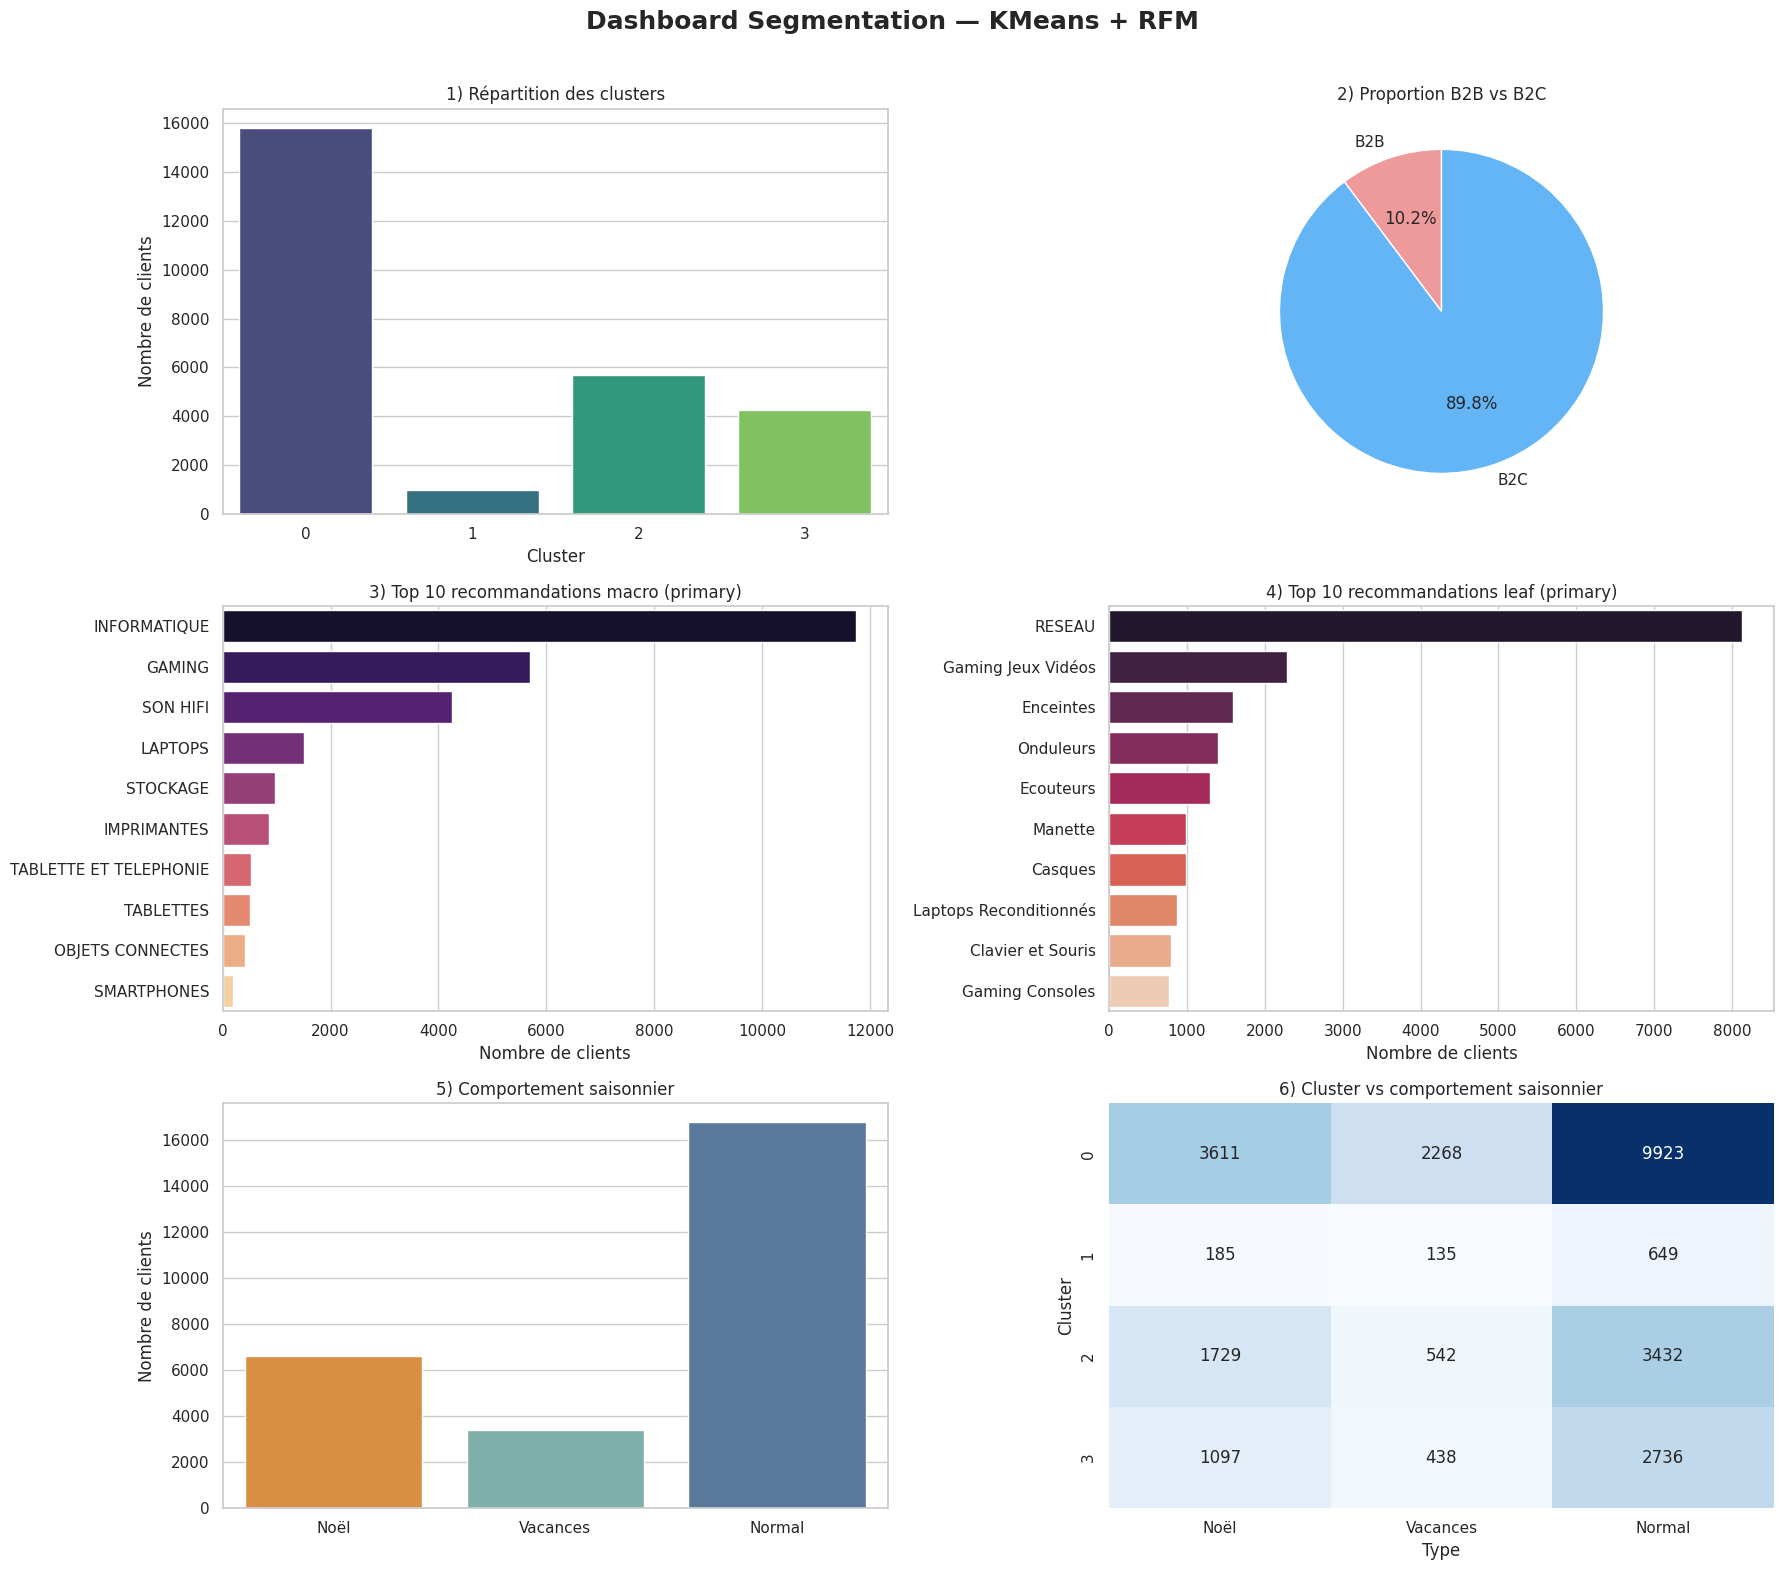


Profil macro par cluster :
 cluster_affinity cluster_profile_macro
                0          INFORMATIQUE
                1              STOCKAGE
                2                GAMING
                3              SON HIFI


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1) Chargement + jointure
# =========================
kmeans = pd.read_csv("data/customer_recommendation.csv")
rfm = pd.read_csv("data/rfm_segments.csv")

df = kmeans.merge(
    rfm[["partner_id", "segment", "Tag_B2B", "Tag_Christmas_Shopper", "Tag_Holidays_Shopper", "Tag_Interest"]],
    on="partner_id",
    how="left",
    suffixes=("", "_rfm")
)

# Normalisation booléens
for col in ["Tag_B2B", "Tag_Christmas_Shopper", "Tag_Holidays_Shopper"]:
    if col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].astype(str).str.lower().map({"true": True, "false": False})
        df[col] = df[col].fillna(False).astype(bool)

# Label comportement saisonnier exclusif
# priorité: Noël > Vacances (Hors Noel) > Normal
df["season_behavior"] = np.where(
    df["Tag_Christmas_Shopper"], "Noël",
    np.where(df["Tag_Holidays_Shopper"], "Vacances (Hors Noel)", "Normal")
)

# =========================
# 2) Tables agrégées
# =========================
n = len(df)

# A) Répartition clusters
cluster_dist = (
    df["cluster_affinity"].value_counts()
    .sort_index()
    .rename_axis("cluster_affinity")
    .reset_index(name="count")
)

# B) Profil macro par cluster (dominante)
cluster_profile = (
    df[["cluster_affinity", "cluster_profile_macro"]]
    .drop_duplicates()
    .sort_values("cluster_affinity")
)

# C) Top 10 macro reco primaire
top_macro = (
    df["recommended_macro_primary"]
    .dropna()
    .astype(str)
    .value_counts()
    .head(10)
    .rename_axis("macro")
    .reset_index(name="count")
)

# D) Top 10 leaf reco primaire
top_leaf = (
    df["recommended_leaf_primary"]
    .dropna()
    .astype(str)
    .value_counts()
    .head(10)
    .rename_axis("leaf")
    .reset_index(name="count")
)

# E) B2B vs B2C
b2b_count = int(df["Tag_B2B"].sum())
b2c_count = n - b2b_count

# F) Noël vs Vacances (Hors Noel) vs Normal
season_dist = (
    df["season_behavior"]
    .value_counts()
    .reindex(["Noël", "Vacances (Hors Noel)", "Normal"], fill_value=0)
    .rename_axis("type")
    .reset_index(name="count")
)

# G) Cluster x saison
cluster_season = pd.crosstab(df["cluster_affinity"], df["season_behavior"])
for c in ["Noël", "Vacances (Hors Noel)", "Normal"]:
    if c not in cluster_season.columns:
        cluster_season[c] = 0
cluster_season = cluster_season[["Noël", "Vacances (Hors Noel)", "Normal"]]

# =========================
# 3) Graphes
# =========================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
fig.suptitle("Dashboard Segmentation — KMeans + RFM", fontsize=18, fontweight="bold")

# 1. Répartition clusters
sns.barplot(data=cluster_dist, x="cluster_affinity", y="count", ax=axes[0, 0], palette="viridis")
axes[0, 0].set_title("1) Répartition des clusters")
axes[0, 0].set_xlabel("Cluster")
axes[0, 0].set_ylabel("Nombre de clients")

# 2. B2B vs B2C
axes[0, 1].pie(
    [b2b_count, b2c_count],
    labels=["B2B", "B2C"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#ef9a9a", "#64b5f6"]
)
axes[0, 1].set_title("2) Proportion B2B vs B2C")

# 3. Top 10 macro reco
sns.barplot(data=top_macro, y="macro", x="count", ax=axes[1, 0], palette="magma")
axes[1, 0].set_title("3) Top 10 recommandations macro (primary)")
axes[1, 0].set_xlabel("Nombre de clients")
axes[1, 0].set_ylabel("")

# 4. Top 10 leaf reco
sns.barplot(data=top_leaf, y="leaf", x="count", ax=axes[1, 1], palette="rocket")
axes[1, 1].set_title("4) Top 10 recommandations leaf (primary)")
axes[1, 1].set_xlabel("Nombre de clients")
axes[1, 1].set_ylabel("")

# 5. Noël vs Vacances (Hors Noel) vs Normal
sns.barplot(data=season_dist, x="type", y="count", ax=axes[2, 0], palette=["#f28e2b", "#76b7b2", "#4e79a7"])
axes[2, 0].set_title("5) Comportement saisonnier")
axes[2, 0].set_xlabel("")
axes[2, 0].set_ylabel("Nombre de clients")

# 6. Heatmap Cluster x Saisonnier
sns.heatmap(cluster_season, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[2, 1])
axes[2, 1].set_title("6) Cluster vs comportement saisonnier")
axes[2, 1].set_xlabel("Type")
axes[2, 1].set_ylabel("Cluster")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [3]:
# =========================
# 4) Tables (mêmes données que les graphes)
# =========================
b2b_vs_b2c = pd.DataFrame(
    {
        "type": ["B2B", "B2C"],
        "count": [b2b_count, b2c_count],
        "pct": [round((b2b_count / n) * 100, 2), round((b2c_count / n) * 100, 2)],
    }
)

display(cluster_dist.rename(columns={"cluster_affinity": "cluster"}))
display(cluster_profile.reset_index(drop=True))
display(top_macro)
display(top_leaf)
display(b2b_vs_b2c)
display(season_dist)
display(cluster_season.reset_index())

,cluster,count
0,0,15802
1,1,969
2,2,5703
3,3,4271


,cluster_affinity,cluster_profile_macro
0,0,INFORMATIQUE
1,1,STOCKAGE
2,2,GAMING
3,3,SON HIFI


,macro,count
0,INFORMATIQUE,11743
1,GAMING,5694
2,SON HIFI,4249
3,LAPTOPS,1500
4,STOCKAGE,969
5,IMPRIMANTES,855
6,TABLETTE ET TELEPHONIE,522
7,TABLETTES,509
8,OBJETS CONNECTES,409
9,SMARTPHONES,198


,leaf,count
0,RESEAU,8130
1,Gaming Jeux Vidéos,2283
2,Enceintes,1588
3,Onduleurs,1399
4,Ecouteurs,1300
5,Manette,991
6,Casques,987
7,Laptops Reconditionnés,875
8,Clavier et Souris,802
9,Gaming Consoles,775


,type,count,pct
0,B2B,2738,10.24
1,B2C,24007,89.76


,type,count
0,Noël,6622
1,Vacances,3383
2,Normal,16740


season_behavior,cluster_affinity,Noël,Vacances,Normal
0,0,3611,2268,9923
1,1,185,135,649
2,2,1729,542,3432
3,3,1097,438,2736
